In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("fraud_oracle.csv")

In [3]:
df

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15415,Nov,4,Friday,Toyota,Urban,Tuesday,Nov,5,Male,Married,...,6 years,31 to 35,No,No,External,none,no change,1 vehicle,1996,Collision
15416,Nov,5,Thursday,Pontiac,Urban,Friday,Dec,1,Male,Married,...,6 years,31 to 35,No,No,External,more than 5,no change,3 to 4,1996,Liability
15417,Nov,5,Thursday,Toyota,Rural,Friday,Dec,1,Male,Single,...,5 years,26 to 30,No,No,External,1 to 2,no change,1 vehicle,1996,Collision
15418,Dec,1,Monday,Toyota,Urban,Thursday,Dec,2,Female,Married,...,2 years,31 to 35,No,No,External,more than 5,no change,1 vehicle,1996,All Perils


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

# Drop Unnecessary Columns

In [5]:
df_clean = df.drop(                      
    columns = ["PolicyNumber",
              "Year",
              "WeekOfMonth",
              "WeekOfMonthClaimed"
              ]
)

In [6]:
df_clean.isnull().sum()

Month                   0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
BasePolicy              0
dtype: int64

In [7]:
df_clean.duplicated().sum()

np.int64(0)

In [8]:
df_clean.head()

,Month,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,Sex,MaritalStatus,Age,Fault,...,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,BasePolicy
0,Dec,Wednesday,Honda,Urban,Tuesday,Jan,Female,Single,21,Policy Holder,...,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,Liability
1,Jan,Wednesday,Honda,Urban,Monday,Jan,Male,Single,34,Policy Holder,...,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,Collision
2,Oct,Friday,Honda,Urban,Thursday,Nov,Male,Married,47,Policy Holder,...,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,Collision
3,Jun,Saturday,Toyota,Rural,Friday,Jul,Male,Married,65,Third Party,...,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,Liability
4,Jan,Monday,Honda,Urban,Tuesday,Feb,Female,Single,27,Third Party,...,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,Collision


In [9]:
df_clean.shape

(15420, 29)

In [10]:
df_clean.columns

Index(['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed',
       'MonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType',
       'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'RepNumber',
       'Deductible', 'DriverRating', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars',
       'BasePolicy'],
      dtype='object')

In [11]:
df_clean.describe()

,Age,FraudFound_P,RepNumber,Deductible,DriverRating
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,39.855707,0.059857,8.483268,407.704280,2.487808
std,13.492377,0.237230,4.599948,43.950998,1.119453
min,0.000000,0.000000,1.000000,300.000000,1.000000
25%,31.000000,0.000000,5.000000,400.000000,1.000000
50%,38.000000,0.000000,8.000000,400.000000,2.000000
75%,48.000000,0.000000,12.000000,400.000000,3.000000
max,80.000000,1.000000,16.000000,700.000000,4.000000


In [12]:
df_clean["FraudFound_P"].value_counts()

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

In [13]:
fraud_rate = df_clean["FraudFound_P"].mean()*100  # Calculate Fraud Percentage

In [59]:
fraud_rate.round(2)

np.float64(5.99)

In [15]:
pd.crosstab(df_clean["Sex"],      # compare two categorical columns and count how many records fall into each combination.
            df_clean["FraudFound_P"]
)

FraudFound_P,0,1
Sex,,
Female,2315,105
Male,12182,818


In [16]:
gender_fraud = pd.crosstab(df_clean["Sex"],df_clean["FraudFound_P"])

gender_fraud["Fraud_rate_%"] = (gender_fraud[1] / (gender_fraud[0] + gender_fraud[1]) * 100).round(2)

In [17]:
gender_fraud   # Calculate Fraud Percentage by Gender

FraudFound_P,0,1,Fraud_rate_%
Sex,,,
Female,2315,105,4.34
Male,12182,818,6.29


In [18]:
df_clean["FraudFound_P"]

0        0
1        0
2        0
3        0
4        0
        ..
15415    1
15416    0
15417    1
15418    0
15419    1
Name: FraudFound_P, Length: 15420, dtype: int64

# Fraud by vehical category

In [61]:
vehicle_fraud = pd.crosstab(
    df_clean["VehicleCategory"],
    df_clean["FraudFound_P"]
)

In [62]:
vehicle_fraud

FraudFound_P,0,1
VehicleCategory,,
Sedan,8876,795
Sport,5274,84
Utility,347,44


In [63]:
vehicle_fraud["Fraud_rate_%"] = (vehical_fraud[1] / (vehical_fraud[0] + vehical_fraud[1])*100).round(2)

In [64]:
vehicle_fraud   # Fraud rate percentage by vehicle category

FraudFound_P,0,1,Fraud_rate_%
VehicleCategory,,,
Sedan,8876,795,8.22
Sport,5274,84,1.57
Utility,347,44,11.25


# Fraud by policy types

In [57]:
policy_fraud = pd.crosstab(
    df_clean["PolicyType"],
    df_clean["FraudFound_P"]
)

In [58]:
policy_fraud

FraudFound_P,0,1
PolicyType,,
Sedan - All Perils,3676,411
Sedan - Collision,5200,384
Sedan - Liability,4951,36
Sport - All Perils,22,0
Sport - Collision,300,48
Sport - Liability,1,0
Utility - All Perils,299,41
Utility - Collision,27,3
Utility - Liability,21,0


In [25]:
policy_fraud["Fraud_Rate_%"] = (policy_fraud[1] / (policy_fraud[0] + policy_fraud[1])*100).round(2)

In [26]:
policy_fraud   # Fraud rate percentage by policy type

FraudFound_P,0,1,Fraud_Rate_%
PolicyType,,,
Sedan - All Perils,3676,411,10.06
Sedan - Collision,5200,384,6.88
Sedan - Liability,4951,36,0.72
Sport - All Perils,22,0,0.00
Sport - Collision,300,48,13.79
Sport - Liability,1,0,0.00
Utility - All Perils,299,41,12.06
Utility - Collision,27,3,10.00
Utility - Liability,21,0,0.00


In [27]:
df_clean["Age"]

0        21
1        34
2        47
3        65
4        27
         ..
15415    35
15416    30
15417    24
15418    34
15419    21
Name: Age, Length: 15420, dtype: int64

# Fill null value of Age column from Median

In [28]:
median_age = df_clean[df_clean["Age"]>0]["Age"].median()

df_clean["Age"] = df_clean["Age"].replace(0, median_age)

# Create Age Group

In [29]:
bins = [0,25,40,60,100]

labels = [
    "Young",
    "Adult",
    "Middle Age",
    "Senior"
]
df_clean["Age_Group"] = pd.cut(
    df_clean["Age"],
    bins=bins,
    labels=labels
)

In [30]:
df_clean["Age_Group"].value_counts()

Age_Group
Adult         7931
Middle Age    5571
Senior        1182
Young          736
Name: count, dtype: int64

In [31]:
df_clean["Age_Group"].isnull().sum()

np.int64(0)

In [32]:
df_clean[df_clean["Age_Group"].isnull()]["Age"].value_counts()

Series([], Name: count, dtype: int64)

In [33]:
df_clean.head()

,Month,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,Sex,MaritalStatus,Age,Fault,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,BasePolicy,Age_Group
0,Dec,Wednesday,Honda,Urban,Tuesday,Jan,Female,Single,21,Policy Holder,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,Liability,Young
1,Jan,Wednesday,Honda,Urban,Monday,Jan,Male,Single,34,Policy Holder,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,Collision,Adult
2,Oct,Friday,Honda,Urban,Thursday,Nov,Male,Married,47,Policy Holder,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,Collision,Middle Age
3,Jun,Saturday,Toyota,Rural,Friday,Jul,Male,Married,65,Third Party,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,Liability,Senior
4,Jan,Monday,Honda,Urban,Tuesday,Feb,Female,Single,27,Third Party,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,Collision,Adult


In [34]:
df_clean["Age"].value_counts().sort_index().head()

Age
16     9
17     6
18    48
19    32
20    28
Name: count, dtype: int64

In [35]:
df_clean["Age"].isnull().sum()

np.int64(0)

In [36]:
df_clean["Age_Group"].value_counts()

Age_Group
Adult         7931
Middle Age    5571
Senior        1182
Young          736
Name: count, dtype: int64

# Fraud by Age Group

In [37]:
age_fraud = pd.crosstab(
    df_clean["Age_Group"],
    df_clean["FraudFound_P"]
)

In [38]:
age_fraud

FraudFound_P,0,1
Age_Group,,
Young,685,51
Adult,7413,518
Middle Age,5283,288
Senior,1116,66


In [39]:
age_fraud["Fraud_Rate_%"] = (age_fraud[1] / (age_fraud[0] + age_fraud[1]) * 100).round(2)

In [40]:
age_fraud  # Fraud percentage by age group

FraudFound_P,0,1,Fraud_Rate_%
Age_Group,,,
Young,685,51,6.93
Adult,7413,518,6.53
Middle Age,5283,288,5.17
Senior,1116,66,5.58


# Police report Fraudsters

In [41]:
police_report = pd.crosstab(
    df_clean["PoliceReportFiled"],
    df_clean["FraudFound_P"]
)

In [42]:
police_report

FraudFound_P,0,1
PoliceReportFiled,,
No,14085,907
Yes,412,16


In [43]:
police_report["Fraud_Rate_%"] = (police_report[1] /(police_report[0] + police_report[1]) * 100).round(2)

In [44]:
police_report

FraudFound_P,0,1,Fraud_Rate_%
PoliceReportFiled,,,
No,14085,907,6.05
Yes,412,16,3.74


# Business Insight

Claims without a police report have a fraud rate of 6.05%.

Claims with a police report have a fraud rate of 3.74%.

Fraud is relatively more common when no police report is filed.

# Witness Presence Fraud

In [45]:
df_clean["WitnessPresent"].value_counts()

WitnessPresent
No     15333
Yes       87
Name: count, dtype: int64

In [46]:
witness_presence = pd.crosstab(
    df_clean["WitnessPresent"],
    df_clean["FraudFound_P"]
)

In [47]:
witness_presence

FraudFound_P,0,1
WitnessPresent,,
No,14413,920
Yes,84,3


In [48]:
witness_presence["Fraud_Rate_%"] = (witness_presence[1] / (witness_presence[0] + witness_presence[1]) * 100).round(2)

In [49]:
witness_presence

FraudFound_P,0,1,Fraud_Rate_%
WitnessPresent,,,
No,14413,920,6.00
Yes,84,3,3.45


# Business Insight

Claims without witnesses have a fraud rate of 6.00%.

Claims with witnesses have a fraud rate of 3.45%.

The fraud rate is almost 1.7 times higher when no witness is present.

In [50]:
(df_clean["WitnessPresent"].value_counts(normalize=True)*100).round(2)

WitnessPresent
No     99.44
Yes     0.56
Name: proportion, dtype: float64

# Graphical representation

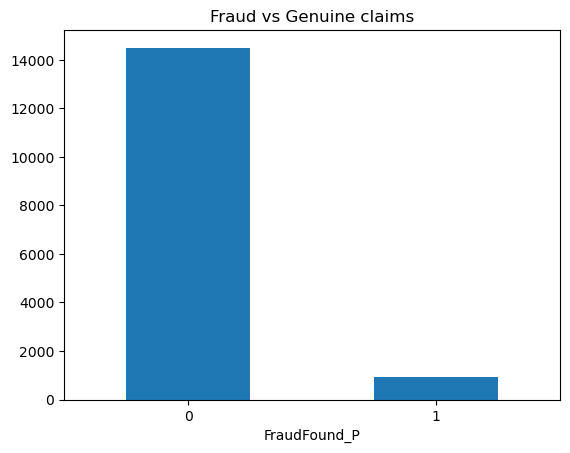

In [56]:
df_clean["FraudFound_P"].value_counts().plot(kind= "bar") 
plt.title("Fraud vs Genuine claims")
plt.xticks(rotation=0)
plt.show()

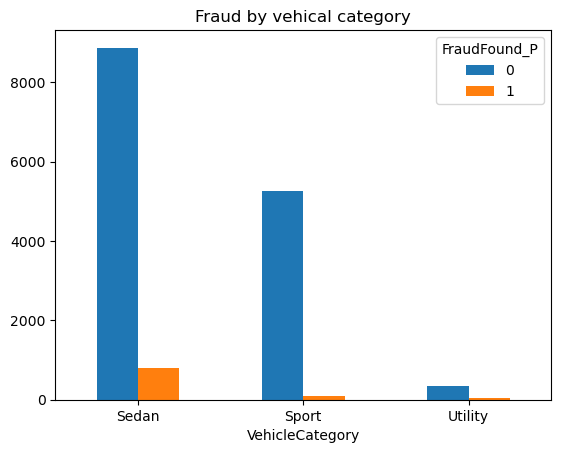

In [55]:
vehical_fraud.plot(kind= "bar")
plt.title("Fraud by vehical category")
plt.xticks(rotation=0)
plt.show()

# Crucial Insights

In [68]:
insight = {
    "Fraud_Rate" : fraud_rate,
    "Most Fraud Vehicle" : vehicle_fraud.sum(axis=1).idxmax()
}

In [67]:
insight

{'Fraud_Rate': np.float64(5.985732814526589), 'Most Fraud Vehicle': 'Sedan'}

# Export Cleaned Dataset

In [69]:
df_clean.to_csv("insurance_cleaned.csv",index=False)